# 02 — Prompt comparison
### Comparer baseline_prompt.txt et improved_prompt.txt sur les mêmes cas.
Mini batch check (sample d'image) pour vérifier la pertinence du model

## 1. Set up
### Import des libraries

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from src.inference import vlm_predict_placeholder
from src.guardrails import apply_safety_guardrails

c:\Users\auber.MSI\Projets\TD-Mastercamp\SolutionDelivery\Assistant-Radiologique-Virtuel-Intelligent-pour-Radiographies-X\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Check le nombre d'images disponibles et le temps pour tester le modèle

In [2]:
data_root = Path('../data')
folder = 'brutes'
total = len(list((data_root / folder).glob('*.jpg')))
print(f"Total images : {total}")
print(f"Temps estimé VLM : ~{total * 40 // 60} minutes")

Total images : 932
Temps estimé VLM : ~621 minutes


## 2. Mini batch
### Resultat du mini batch extraits de `results\ batch_results.csv`
Run avec le fichier : `scripts\run_batch.py` (30 cas pour éviter les problèmes de gpu)

In [3]:
# print batch_results.csv saved under results directory as csvfile
df_final = pd.read_csv('../results/batch_results.csv')
display(df_final)

,case_id,file,path,folder,ground_truth,toy_class,toy_confidence,vlm_baseline_class,vlm_baseline_confidence,vlm_improved_class,vlm_improved_confidence
0,1,NORMAL-LUNG_00115_normal_142.jpg,data\normal_lung_probe\NORMAL-LUNG_00115_norma...,normal_lung_probe,normal,normal,0.743,normal,0.95,normal,0.8
1,2,NORMAL-LUNG_00026_normal_036.jpg,data\normal_lung_probe\NORMAL-LUNG_00026_norma...,normal_lung_probe,normal,normal,0.730,normal,0.95,normal,0.8
2,3,NORMAL-LUNG_00282_normal_320.jpg,data\normal_lung_probe\NORMAL-LUNG_00282_norma...,normal_lung_probe,normal,normal,0.752,normal,0.95,normal,0.8
3,4,NORMAL-LUNG_00251_normal_285.jpg,data\normal_lung_probe\NORMAL-LUNG_00251_norma...,normal_lung_probe,normal,normal,0.728,normal,0.95,normal,0.8
4,5,NORMAL-LUNG_00229_normal_262.jpg,data\normal_lung_probe\NORMAL-LUNG_00229_norma...,normal_lung_probe,normal,normal,0.739,normal,0.95,normal,0.8
5,6,ABNORMAL-LUNG_00143_suspected_opacity_152.jpg,data\lung_images\ABNORMAL-LUNG_00143_suspected...,lung_images,suspected_opacity,suspected_opacity,0.704,normal,0.95,normal,0.8
6,7,NORMAL-LUNG_00755_normal_374.jpg,data\lung_images\NORMAL-LUNG_00755_normal_374.jpg,lung_images,normal,normal,0.731,normal,0.80,normal,0.8
7,8,ABNORMAL-LUNG_00105_suspected_opacity_112.jpg,data\lung_images\ABNORMAL-LUNG_00105_suspected...,lung_images,suspected_opacity,suspected_opacity,0.717,suspected_opacity,0.30,normal,0.8
8,9,NORMAL-LUNG_00693_normal_308.jpg,data\lung_images\NORMAL-LUNG_00693_normal_308.jpg,lung_images,normal,normal,0.747,normal,0.95,normal,0.8
9,10,NORMAL-LUNG_00759_normal_378.jpg,data\lung_images\NORMAL-LUNG_00759_normal_378.jpg,lung_images,normal,normal,0.714,normal,0.95,normal,0.8


### Calculs des métriques pour la comparaison


=== VLM Baseline ===
Total : 15
Taux uncertain    : 6.7%
Accuracy : 60.0%
Macro F1 : 0.337
Sensibilité : 14.3%
Spécificité : 61.5%


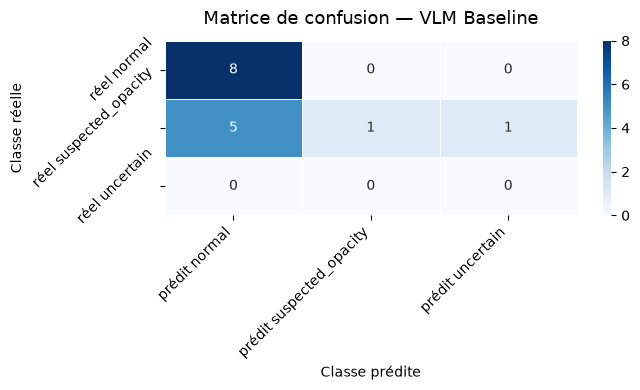


=== VLM Improved ===
Total : 15
Taux uncertain    : 0.0%
Accuracy : 53.3%
Macro F1 : 0.232
Sensibilité : 0.0%
Spécificité : 53.3%


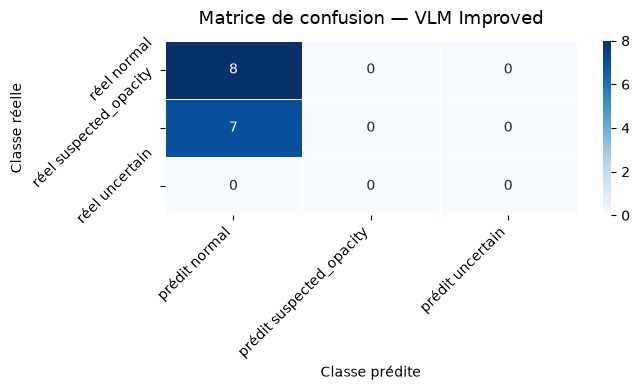

In [4]:
from src.metrics import summarize_metrics, confusion_matrix_numpy

df_final = pd.read_csv('../results/batch_results.csv')

CLASSES = ['normal', 'suspected_opacity', 'uncertain']
modes = {
    'VLM Baseline': 'vlm_baseline_class',
    'VLM Improved': 'vlm_improved_class',
}

for label, col in modes.items():
    print(f"\n=== {label} ===")
    valid = df_final[df_final[col].notna() & (df_final[col] != 'error')].copy()

    # Métriques globales (uncertain inclus)
    rows = [{"label": t, "predicted_class": p, "warning": True}
            for t, p in zip(valid['ground_truth'], valid[col])]
    m = summarize_metrics(rows)
    print(f"Total : {m['n']}")
    print(f"Taux uncertain    : {m['uncertain_rate']:.1%}")
    print(f"Accuracy : {m['accuracy']:.1%}")
    print(f"Macro F1 : {m['macro_f1']:.3f}")
    print(f"Sensibilité : {m['sensitivity']:.1%}")
    print(f"Spécificité : {m['specificity']:.1%}")

    # Matrice de confusion
    cm = confusion_matrix_numpy(valid['ground_truth'], valid[col], CLASSES)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {c}' for c in CLASSES],
        columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — {label}', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 3. Résultats des runs sauvegardés dans la database

### Affichage de la table à étudier (join run et evaluation)

In [5]:
# Chemin vers la DB
DB_PATH = Path('../data/database.sqlite')

In [6]:
from src.database import get_evaluations

rows = get_evaluations(DB_PATH)
df = pd.DataFrame(rows)

df.head()


,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
0,17,1,1,1,baseline,v0,suspected_opacity,normal,0.95,52971
1,29,83,83,1,baseline,v0,suspected_opacity,normal,0.95,35864
2,34,50,50,1,baseline,v0,suspected_opacity,normal,0.95,39044
3,37,55,55,1,baseline,v0,suspected_opacity,normal,0.80,44824
4,72,62,62,1,baseline,v0,suspected_opacity,normal,0.95,35904


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   case_id             228 non-null    int64  
 1   run_id              228 non-null    int64  
 2   evaluation_id       228 non-null    int64  
 3   prompt_id           228 non-null    int64  
 4   prompt_name         228 non-null    str    
 5   prompt_version      228 non-null    str    
 6   ground_truth_label  228 non-null    str    
 7   predicted_class     228 non-null    str    
 8   confidence          228 non-null    float64
 9   latency             228 non-null    int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 24.2 KB


In [8]:
# Improved prompt
df_version = df[df['prompt_id'] == 2 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
100,17,101,101,2,improved,v1,suspected_opacity,normal,0.8,32854
101,29,183,183,2,improved,v1,suspected_opacity,normal,0.8,33556
102,34,150,150,2,improved,v1,suspected_opacity,normal,0.8,40038
103,37,155,155,2,improved,v1,suspected_opacity,normal,0.8,40375
104,72,162,162,2,improved,v1,suspected_opacity,normal,0.8,33489
...,...,...,...,...,...,...,...,...,...,...
195,849,159,159,2,improved,v1,normal,normal,0.8,37080
196,852,182,182,2,improved,v1,normal,normal,0.8,41933
197,879,130,130,2,improved,v1,normal,normal,0.8,41835
198,884,195,195,2,improved,v1,normal,normal,0.8,39508



=== VLM baseline 0 ===
Total : 100
Taux uncertain : 17.0%
Accuracy : 53.0%
Macro F1 : 0.311
Sensibilité : 10.0%
Spécificité : 61.5%


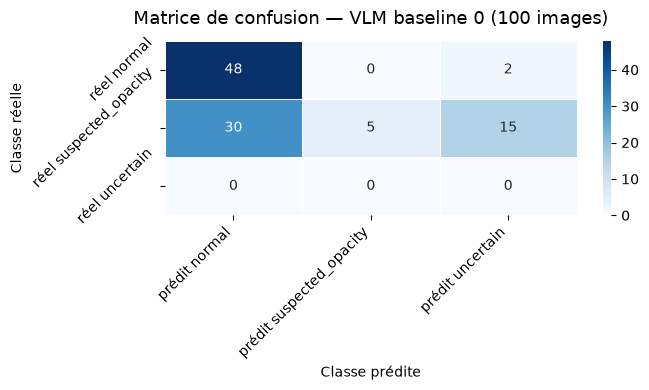


=== VLM improved 1 ===
Total : 100
Taux uncertain : 1.0%
Accuracy : 50.0%
Macro F1 : 0.224
Sensibilité : 0.0%
Spécificité : 50.5%


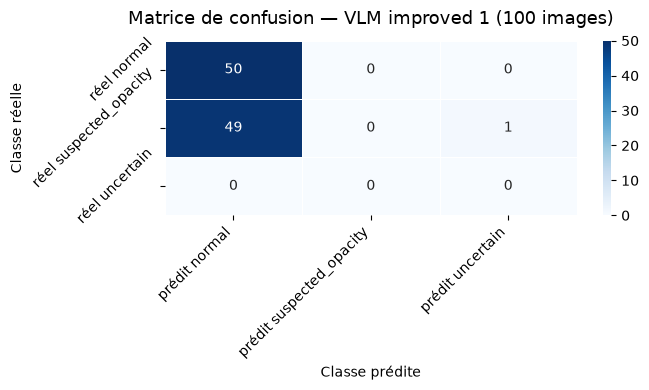


=== VLM improved 2 ===
Total : 24
Taux uncertain : 0.0%
Accuracy : 50.0%
Macro F1 : 0.222
Sensibilité : 0.0%
Spécificité : 50.0%


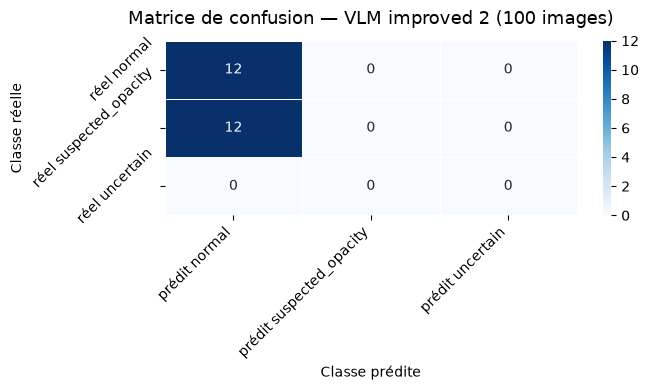


=== VLM improved 3 ===
Total : 4
Taux uncertain : 0.0%
Accuracy : 100.0%
Macro F1 : 0.667
Sensibilité : 100.0%
Spécificité : 100.0%


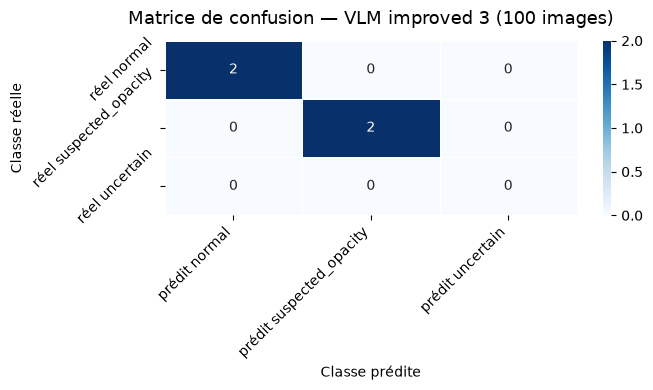

In [12]:
from src.metrics import sensitivity, specificity, confusion_matrix_numpy

CLASSES = ['normal', 'suspected_opacity', 'uncertain']

def compute_metrics_df(df, gt_col='ground_truth_label', pred_col='predicted_class'):
    valid = df.dropna(subset=[gt_col, pred_col])
    n = len(valid)
    accuracy = (valid[gt_col] == valid[pred_col]).mean()
    uncertain_rate = (valid[pred_col] == 'uncertain').mean()

    cm = confusion_matrix_numpy(valid[gt_col], valid[pred_col], CLASSES)
    
    f1_scores = []
    for i, cls in enumerate(CLASSES):
        tp = cm[i][i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        f1_scores.append(f1)
    macro_f1 = sum(f1_scores) / len(f1_scores)

    return {
        'n': n,
        'accuracy': accuracy,
        'macro_f1': macro_f1,
        'sensitivity': sensitivity(valid[gt_col], valid[pred_col]),
        'specificity': specificity(valid[gt_col], valid[pred_col]),
        'uncertain_rate': uncertain_rate,
    }
prompts = {0: "baseline", 1: "improved", 2:"improved", 3:"improved"}

for version in prompts :
    df_version = df[df['prompt_id'] == version +1 ]
    # print(df_version)
    
    PROMPT_NAME = prompts[version]
    PROMPT_VERSION = version

    m = compute_metrics_df(df_version)

    print(f'\n=== VLM {PROMPT_NAME} {PROMPT_VERSION} ===')
    print(f'Total : {m["n"]}')
    print(f'Taux uncertain : {m["uncertain_rate"]:.1%}')
    print(f'Accuracy : {m["accuracy"]:.1%}')
    print(f'Macro F1 : {m["macro_f1"]:.3f}')
    print(f'Sensibilité : {m["sensitivity"]:.1%}')
    print(f'Spécificité : {m["specificity"]:.1%}')

    # Matrice de confusion
    cm = confusion_matrix_numpy(df_version['ground_truth_label'], df_version['predicted_class'], CLASSES)
    cm_df = pd.DataFrame(cm,
        index=[f'réel {c}' for c in CLASSES],
        columns=[f'prédit {c}' for c in CLASSES])

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title(f'Matrice de confusion — VLM {PROMPT_NAME} {PROMPT_VERSION} (100 images)', fontsize=13, pad=12)
    ax.set_ylabel('Classe réelle')
    ax.set_xlabel('Classe prédite')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [10]:
df_version = df[df['prompt_id'] == 3 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
200,1,212,212,3,improved,v2,suspected_opacity,normal,0.8,39354
201,5,213,213,3,improved,v2,suspected_opacity,normal,0.8,36195
202,12,214,214,3,improved,v2,suspected_opacity,normal,0.8,36402
203,17,201,201,3,improved,v2,suspected_opacity,normal,0.8,52288
204,18,221,221,3,improved,v2,suspected_opacity,normal,0.8,42063
205,19,222,222,3,improved,v2,suspected_opacity,normal,0.8,40502
206,42,215,215,3,improved,v2,suspected_opacity,normal,0.8,35247
207,53,207,207,3,improved,v2,suspected_opacity,normal,0.8,42279
208,72,206,206,3,improved,v2,suspected_opacity,normal,0.8,35388
209,347,211,211,3,improved,v2,suspected_opacity,normal,0.8,42113


In [11]:
df_version = df[df['prompt_id'] == 4 ]
df_version

,case_id,run_id,evaluation_id,prompt_id,prompt_name,prompt_version,ground_truth_label,predicted_class,confidence,latency
224,18,225,225,4,improved,v3,suspected_opacity,suspected_opacity,0.75,62959
225,19,226,226,4,improved,v3,suspected_opacity,suspected_opacity,0.75,57847
226,620,227,227,4,improved,v3,normal,normal,0.85,53230
227,622,228,228,4,improved,v3,normal,normal,0.85,51957
